# Análise exploratória espacial de dengue e saneamento com PySAL

## tl;dr

- A base integrada de 2022 possui **4.678 municípios completos**, equivalentes a **83,99%** dos 5.570 municípios da malha; todos os códigos da base encontraram geometria.
- A taxa de casos confirmados de dengue apresentou autocorrelação espacial positiva (**Moran I = 0,407; p simulado = 0,001**), portanto municípios com taxas semelhantes tendem a estar próximos no recorte analisado.
- Os indicadores de saneamento também apresentaram agrupamento espacial: água (**I = 0,479**), esgoto (**I = 0,713**) e lixo coletado (**I = 0,466**), todos com `p_sim = 0,001`.
- O LISA identificou **469 municípios Alto–Alto**, **1.348 Baixo–Baixo**, 154 Baixo–Alto e 38 Alto–Baixo para a taxa de dengue (`p_sim < 0,05`).
- Os Morans bivariados entre dengue local e saneamento da vizinhança foram positivos, porém modestos (`I` entre 0,090 e 0,151). São associações ecológicas brutas e **não demonstram causalidade**.

## Contexto e métodos

O notebook combina `sinan/processados/sinan_saneamento_2022.parquet` com a malha municipal simplificada fornecida pela API de Malhas do IBGE. A análise usa o ecossistema PySAL:

- `libpysal.weights.KNN` para a matriz de pesos espaciais;
- `esda.Moran`, `esda.Moran_BV` e `esda.Moran_Local` para autocorrelação global, bivariada e local;
- `splot.esda` para os diagramas de Moran e o mapa LISA;
- `mapclassify`, por meio do GeoPandas, para o mapa coroplético quantílico.

### Principais premissas

1. A unidade de análise é município de notificação em 2022.
2. Os pesos usam os oito centroides municipais mais próximos (`KNN`, `k=8`) em `EPSG:5880`, uma projeção métrica para o Brasil, e são padronizados por linha.
3. KNN foi preferido porque 892 municípios da malha não possuem linha no recorte SINAN 2022; usar contiguidade apenas sobre os municípios observados criaria vizinhanças interrompidas pelas lacunas.
4. Não se presume que município ausente tenha zero casos. Esses municípios permanecem sem valor e aparecem em cinza.
5. A inferência usa 999 permutações com sementes fixas. `p_sim = 0,001` é o menor valor possível com esse número de permutações.
6. A análise é exploratória, espacial e ecológica; não controla clima, urbanização, estrutura etária, acesso ao diagnóstico ou subnotificação.

## Dados

### 1. Preparar o ambiente e os parâmetros

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import spatial_analysis as spatial

warnings.filterwarnings(
    "ignore",
    message="Casting complex values to real discards the imaginary part",
)

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "sinan/processados/sinan_saneamento_2022.parquet"
BOUNDARY_PATH = PROJECT_ROOT / "sinan/processados/ibge_municipios_min.geojson"
FIGURE_DIR = PROJECT_ROOT / "figuras/analise_espacial"
RESULT_DIR = PROJECT_ROOT / "sinan/processados/analise_espacial"

K_NEIGHBORS = 8
PERMUTATIONS = 999
SEED = 42
ALPHA = 0.05

pd.set_option("display.max_colwidth", 80)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

### 2. Carregar a malha e auditar a integração

In [2]:
full_map, analysis_map, geographic_audit = spatial.load_spatial_data(
    data_path=DATA_PATH,
    boundary_path=BOUNDARY_PATH,
)

display(
    geographic_audit.style.format(
        {"valor": lambda value: f"{value:,.2f}" if value % 1 else f"{value:,.0f}"}
    )
)

,metrica,valor
0,municipios_malha,"5,570"
1,municipios_base_analitica,"4,678"
2,municipios_completos_analise,"4,678"
3,municipios_base_sem_geometria,0
4,cobertura_percentual_malha,83.99


A auditoria distingue cobertura analítica de qualidade do vínculo. Os 4.678 registros foram ligados à geometria; a cobertura de 83,99% decorre da ausência de linha SINAN para 892 municípios, não de falha no código municipal.

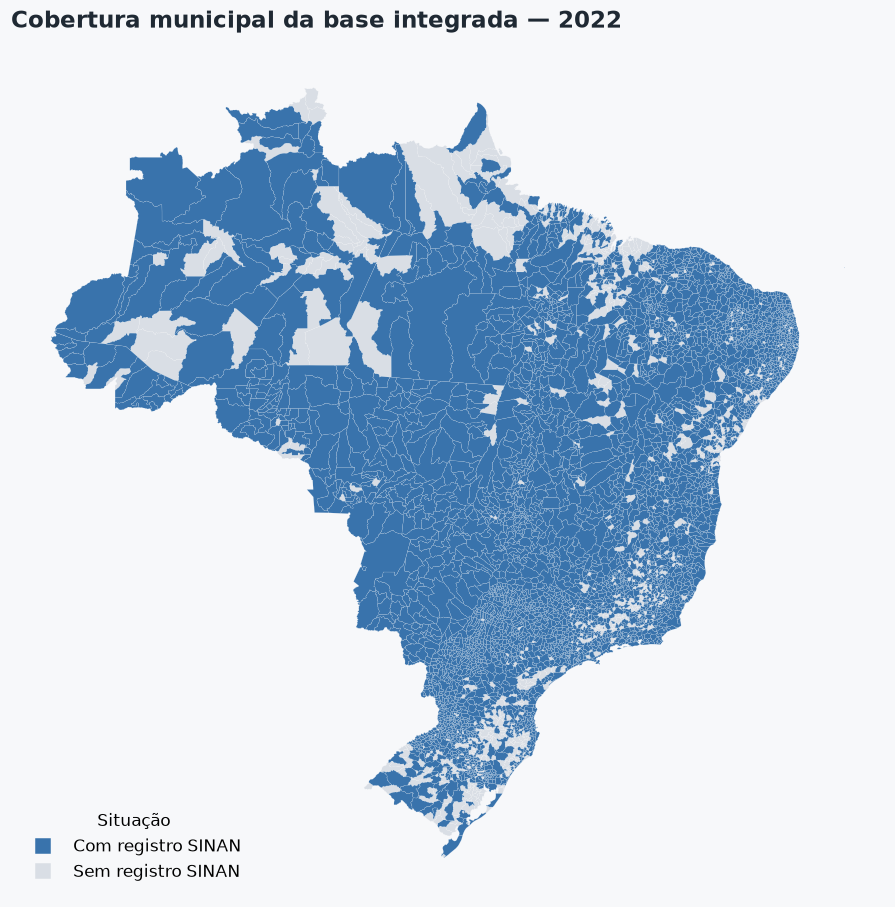

In [3]:
coverage_figure, _ = spatial.plot_data_coverage(full_map)
spatial.save_figure(coverage_figure, FIGURE_DIR / "01_cobertura_sinan_2022.png")
plt.show()

### 3. Construir e verificar os pesos espaciais

In [4]:
weights = spatial.build_knn_weights(analysis_map, k=K_NEIGHBORS)

weights_summary = pd.DataFrame(
    {
        "observacoes": [weights.n],
        "vizinhos_por_municipio": [K_NEIGHBORS],
        "ilhas": [len(weights.islands)],
        "transformacao": [weights.transform],
    }
)
display(weights_summary)

,observacoes,vizinhos_por_municipio,ilhas,transformacao
0,4678,8,0,R


## Resultados

### 4. Distribuição geográfica da taxa de dengue

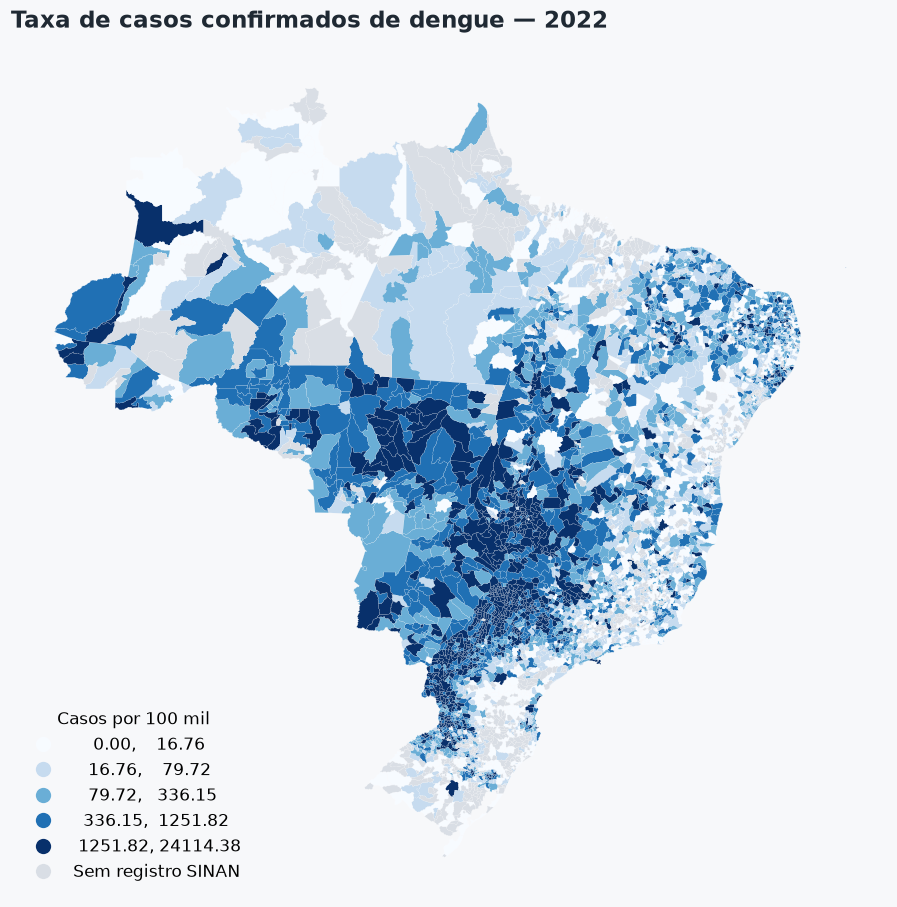

In [5]:
rate_figure, _ = spatial.plot_rate_choropleth(full_map)
spatial.save_figure(rate_figure, FIGURE_DIR / "02_taxa_confirmados_2022.png")
plt.show()

O mapa usa quintis entre os municípios observados para evidenciar a posição relativa, e não faixas epidemiológicas normativas. As maiores classes se concentram visualmente sobretudo no Centro-Oeste e em partes do Sul e Sudeste, enquanto as lacunas de cobertura permanecem em cinza.

### 5. Autocorrelação espacial global

In [6]:
global_moran, global_models = spatial.calculate_global_moran(
    analysis_map,
    weights,
    permutations=PERMUTATIONS,
    seed=SEED,
)

display(
    global_moran[
        ["indicador", "n", "media", "desvio_padrao", "moran_i", "p_sim"]
    ].style.format(
        {
            "media": "{:.2f}",
            "desvio_padrao": "{:.2f}",
            "moran_i": "{:.3f}",
            "p_sim": "{:.3f}",
        }
    )
)

,indicador,n,media,desvio_padrao,moran_i,p_sim
0,Casos confirmados de dengue por 100 mil habitantes,4678,1008.84,2224.58,0.407,0.001
1,Domicílios com rede geral como principal abastecimento (%),4678,73.24,19.15,0.479,0.001
2,Domicílios com esgoto em rede geral ou pluvial (%),4678,36.51,33.50,0.713,0.001
3,Domicílios com lixo coletado no domicílio (%),4678,74.09,19.01,0.466,0.001


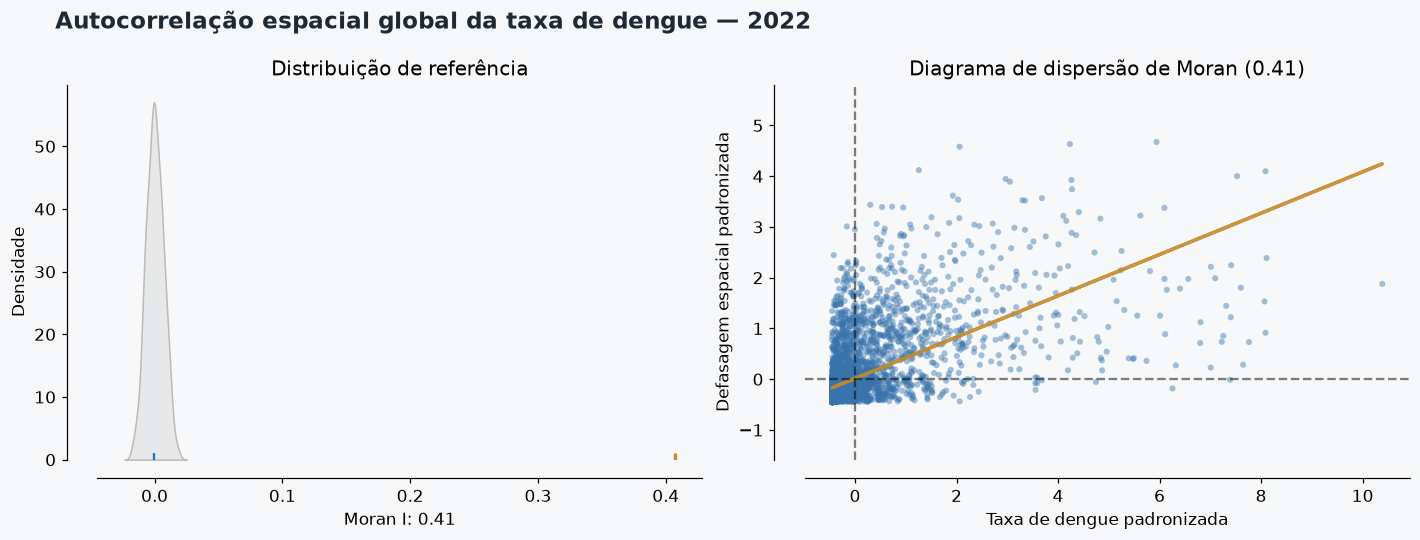

In [7]:
moran_figure, _ = spatial.plot_global_moran_result(
    global_models["taxa_confirmados_100k"],
    "Autocorrelação espacial global da taxa de dengue — 2022",
)
spatial.save_figure(moran_figure, FIGURE_DIR / "03_moran_global_taxa_2022.png")
plt.show()

O `I` positivo de 0,407 é incompatível com uma distribuição espacial aleatória sob as 999 permutações. O resultado descreve agrupamento, mas não identifica sozinho onde estão os clusters nem explica seus mecanismos.

### 6. Sensibilidade ao número de vizinhos

In [8]:
knn_sensitivity = spatial.calculate_knn_sensitivity(
    analysis_map,
    neighbors=(4, 8, 12, 16),
    permutations=PERMUTATIONS,
    seed=SEED + 300,
)
display(knn_sensitivity.style.format({"moran_i": "{:.3f}", "p_sim": "{:.3f}", "z_sim": "{:.2f}"}))

,k_vizinhos,moran_i,p_sim,z_sim,permutacoes
0,4,0.447,0.001,46.20,999
1,8,0.407,0.001,57.37,999
2,12,0.395,0.001,69.08,999
3,16,0.384,0.001,77.26,999


O sinal e a conclusão inferencial devem permanecer estáveis nas quatro configurações para que o agrupamento global não dependa exclusivamente de `k=8`.

### 7. Autocorrelação local — LISA

In [9]:
lisa_map, local_moran = spatial.calculate_local_moran(
    analysis_map,
    weights,
    variable="taxa_confirmados_100k",
    permutations=PERMUTATIONS,
    seed=SEED + 200,
    alpha=ALPHA,
)

cluster_order = [
    "Alto–Alto",
    "Baixo–Baixo",
    "Baixo–Alto",
    "Alto–Baixo",
    "Não significativo",
]
cluster_summary = (
    lisa_map["lisa_cluster"]
    .value_counts()
    .reindex(cluster_order, fill_value=0)
    .rename_axis("cluster")
    .reset_index(name="municipios")
)
display(cluster_summary)

,cluster,municipios
0,Alto–Alto,469
1,Baixo–Baixo,1348
2,Baixo–Alto,154
3,Alto–Baixo,38
4,Não significativo,2669


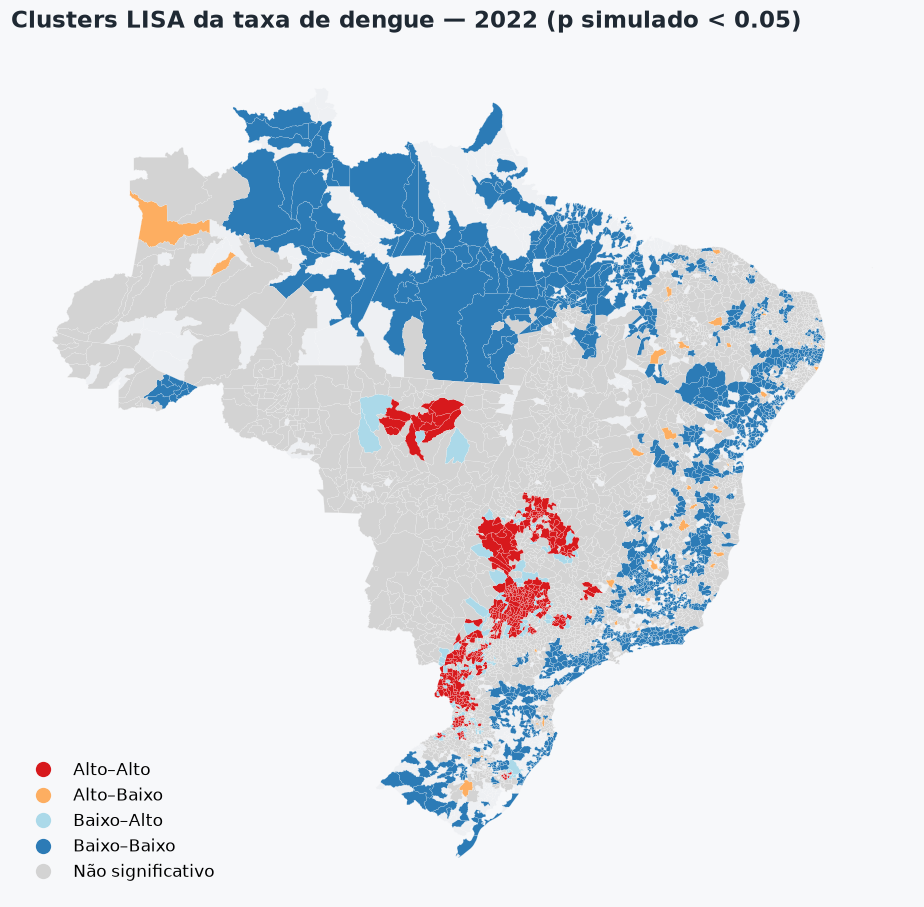

In [10]:
lisa_figure, _ = spatial.plot_lisa_clusters(
    full_map,
    lisa_map,
    local_moran,
    alpha=ALPHA,
)
spatial.save_figure(lisa_figure, FIGURE_DIR / "04_lisa_taxa_2022.png")
plt.show()

Os clusters Alto–Alto indicam municípios com taxa acima da média cercados por vizinhos também acima da média. Eles aparecem principalmente em partes de São Paulo, Paraná, Mato Grosso do Sul, Goiás e Rio Grande do Sul. Baixo–Baixo predomina em áreas do Norte e do litoral oriental. Municípios não significativos e sem registro SINAN não devem ser interpretados como clusters.

In [11]:
high_high = (
    lisa_map.loc[lisa_map["lisa_cluster"].eq("Alto–Alto")]
    .nlargest(10, "taxa_confirmados_100k")
    [["municipio", "taxa_confirmados_100k", "lisa_i", "lisa_p_sim"]]
)
display(
    high_high.style.format(
        {
            "taxa_confirmados_100k": "{:.1f}",
            "lisa_i": "{:.3f}",
            "lisa_p_sim": "{:.3f}",
        }
    )
)

,municipio,taxa_confirmados_100k,lisa_i,lisa_p_sim
3455,Iracema do Oeste - PR,24114.4,19.495,0.001
3205,Santa Mercedes - SP,19046.0,19.357,0.001
2880,Garça - SP,18997.9,7.391,0.020
3296,Urânia - SP,18996.9,33.117,0.001
3542,Ourizona - PR,18952.0,12.344,0.004
3662,Terra Boa - PR,18271.9,5.670,0.045
2892,Guaraçaí - SP,17914.3,13.691,0.001
3211,Santa Salete - SP,17750.8,30.101,0.001
4031,Jaboticaba - RS,17491.4,16.636,0.001
3801,Mondaí - SC,17474.7,9.026,0.012


### 8. Moran bivariado: dengue local e saneamento da vizinhança

In [12]:
bivariate_moran, bivariate_models = spatial.calculate_bivariate_moran(
    analysis_map,
    weights,
    permutations=PERMUTATIONS,
    seed=SEED + 100,
)
display(
    bivariate_moran[
        ["indicador_vizinhanca", "n", "moran_bivariado_i", "p_sim"]
    ].style.format({"moran_bivariado_i": "{:.3f}", "p_sim": "{:.3f}"})
)

,indicador_vizinhanca,n,moran_bivariado_i,p_sim
0,Domicílios com rede geral como principal abastecimento (%),4678,0.125,0.001
1,Domicílios com esgoto em rede geral ou pluvial (%),4678,0.090,0.001
2,Domicílios com lixo coletado no domicílio (%),4678,0.151,0.001


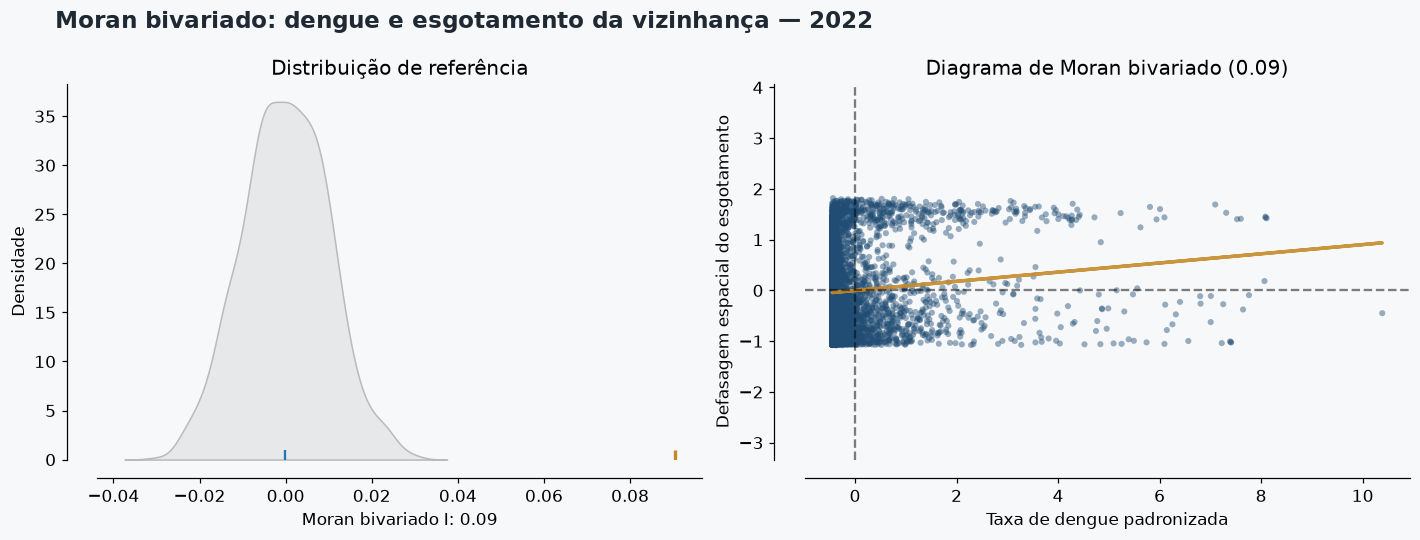

In [13]:
bivariate_figure, _ = spatial.plot_bivariate_moran_result(
    bivariate_models["pct_esgoto_rede_geral_ou_pluvial"],
    "Moran bivariado: dengue e esgotamento da vizinhança — 2022",
)
spatial.save_figure(
    bivariate_figure,
    FIGURE_DIR / "05_moran_bivariado_esgoto_2022.png",
)
plt.show()

Os coeficientes bivariados são positivos e pequenos. Isso significa que, neste recorte bruto, taxas locais mais altas de dengue tendem fracamente a ocorrer próximas de municípios com percentuais mais altos dos serviços observados. O resultado não deve ser lido como efeito protetor ou prejudicial do saneamento: urbanização, densidade, diagnóstico, clima e outros fatores podem produzir a associação espacial.

### 9. Salvar tabelas reproduzíveis

In [14]:
RESULT_DIR.mkdir(parents=True, exist_ok=True)
geographic_audit.to_csv(RESULT_DIR / "auditoria_geografica_2022.csv", index=False)
global_moran.to_csv(RESULT_DIR / "moran_global_2022.csv", index=False)
bivariate_moran.to_csv(RESULT_DIR / "moran_bivariado_2022.csv", index=False)
knn_sensitivity.to_csv(RESULT_DIR / "sensibilidade_knn_2022.csv", index=False)
lisa_map.drop(columns="geometry").to_csv(
    RESULT_DIR / "lisa_taxa_confirmados_2022.csv",
    index=False,
)

sorted(path.name for path in FIGURE_DIR.glob("*.png"))

['01_cobertura_sinan_2022.png',
 '02_taxa_confirmados_2022.png',
 '03_moran_global_taxa_2022.png',
 '04_lisa_taxa_2022.png',
 '05_moran_bivariado_esgoto_2022.png']

## Takeaways

1. Existe dependência espacial relevante na taxa municipal de dengue em 2022; análises posteriores não devem assumir independência entre municípios.
2. O mapa LISA oferece um recorte mais acionável que o mapa de taxas isolado, pois distingue aglomerados espaciais de valores altos, baixos e outliers locais.
3. Esgotamento é o indicador de saneamento com maior autocorrelação própria, mas as relações espaciais bivariadas com dengue são modestas e não causais.
4. Antes de modelar risco, é necessário decidir como tratar os 892 municípios sem linha SINAN e acrescentar covariáveis climáticas, urbanas e demográficas.
5. A multiplicidade dos 4.678 testes LISA deve ser considerada em análises confirmatórias; aqui `p_sim < 0,05` é usado apenas para exploração.

### Reexecução

Execute o notebook de cima para baixo ou use:

```bash
uv run python spatial_analysis.py
uv run jupyter nbconvert --execute --to notebook --inplace analise_espacial_pysal.ipynb
```